In [1]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
from pathlib import Path
import sys

ROOT_DIR = Path('./').resolve().parent
if str(ROOT_DIR) not in sys.path:
    sys.path.append(str(ROOT_DIR))

from db.utils import get_monthly_report
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
import pandas as pd
from pandas.plotting import autocorrelation_plot
import numpy as np


pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
# H0 - ряд стаціонарний
# p-value < 0.05 - відхиляємо H0

def kpss_test(timeseries):
    print("Results of KPSS Test:")
    kpsstest = kpss(timeseries, regression="ct", nlags="auto")
    kpss_output = pd.Series(
        kpsstest[0:3], index=["Test Statistic", "p-value", "Lags Used"]
    )
    for key, value in kpsstest[3].items():
        kpss_output["Critical Value (%s)" % key] = value
    print(kpss_output)

# H0 - ряд нестаціонарний
# p-value < 0.05 - відхиляємо H0

def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC", regression="ct")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

In [3]:
con = duckdb.connect("../charity_reports.duckdb")

In [4]:
savelife_df = con.execute(
"""
SELECT 
    DATE(date_from) AS day,
    COUNT(amount) AS transactions_count
FROM charity_reports
WHERE fund_name='savelife'
GROUP BY DATE(date_from)
ORDER BY day;
""").df()
savelife_df.describe()
savelife_df = savelife_df.set_index("day")

## Розподіл донатів по дням

<Axes: xlabel='day'>

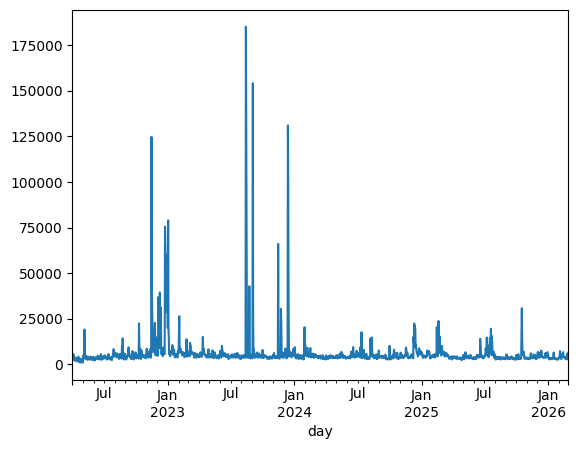

In [5]:
savelife_df["transactions_count"].plot()

### Беремо ряд донатів, обмежуємо вплив аномальних піків (замінюємо значення вище 95-го перцентиля на медіану), аналізуємо розподіл за допомогою гістограми.


C:\Users\user\AppData\Local\Temp\ipykernel_26448\3943983338.py:3: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  max_value = float(savelife_df.quantile(0.95))
C:\Users\user\AppData\Local\Temp\ipykernel_26448\3943983338.py:4: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  median = float(savelife_df.median())


<Axes: >

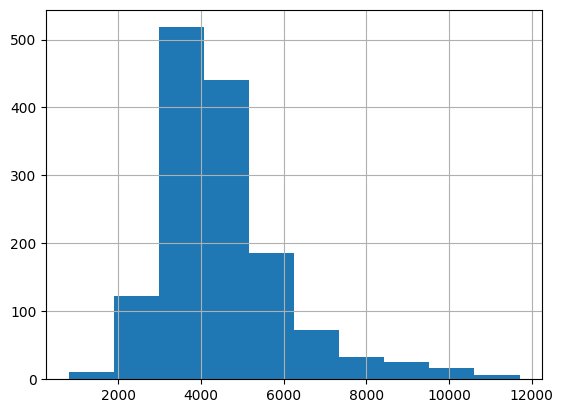

In [6]:
donations = savelife_df.copy()["transactions_count"]

max_value = float(savelife_df.quantile(0.95))
median = float(savelife_df.median())
donations[donations > max_value] = median
donations.hist()

<Axes: xlabel='day'>

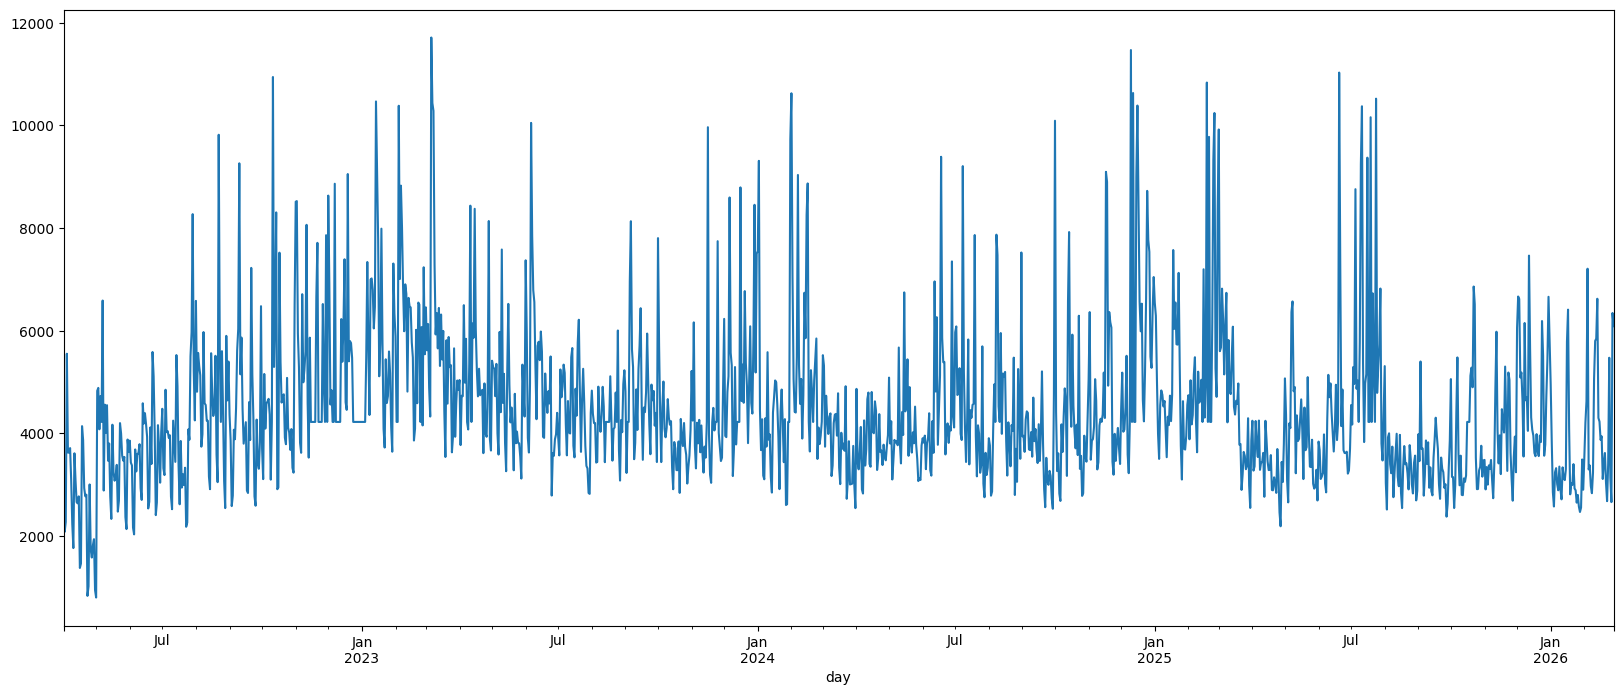

In [7]:
fig, ax = plt.subplots(figsize=(20, 8))
donations.plot(ax=ax)

In [8]:
adf_test(donations)
kpss_test(donations)

Results of Dickey-Fuller Test:
Test Statistic                  -5.03
p-value                          0.00
#Lags Used                      21.00
Number of Observations Used   1408.00
Critical Value (1%)             -3.97
Critical Value (5%)             -3.41
Critical Value (10%)            -3.13
dtype: float64
Results of KPSS Test:
Test Statistic           0.25
p-value                  0.01
Lags Used               20.00
Critical Value (10%)     0.12
Critical Value (5%)      0.15
Critical Value (2.5%)    0.18
Critical Value (1%)      0.22
dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_26448\990589252.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpsstest = kpss(timeseries, regression="ct", nlags="auto")


### ADF тест показує, що ряд є стаціонарним (p-value ≈ 0), тоді як KPSS тест вказує на нестаціонарність (p-value < 0.05). Це свідчить про наявність слабкого тренду або структурних змін у даних. Розглянемо сезонну декомпозицію.

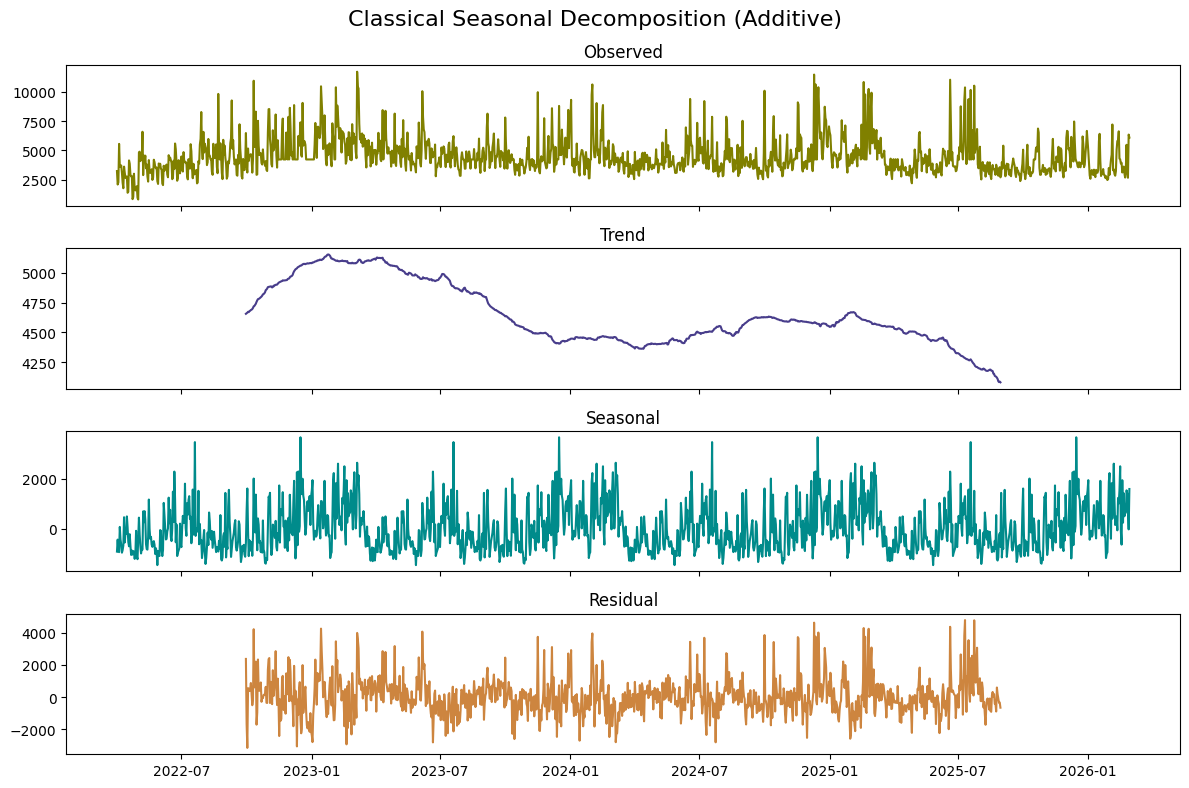

In [9]:
# Apply classical seasonal decomposition
decomposition = seasonal_decompose(donations, model='additive', period=365)

# Plot with custom colors
fig, axs = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

axs[0].plot(decomposition.observed, color='olive')
axs[0].set_title('Observed')

axs[1].plot(decomposition.trend, color='darkslateblue')
axs[1].set_title('Trend')

axs[2].plot(decomposition.seasonal, color='darkcyan')
axs[2].set_title('Seasonal')

axs[3].plot(decomposition.resid, color='peru')
axs[3].set_title('Residual')

plt.suptitle('Classical Seasonal Decomposition (Additive)', fontsize=16)
plt.tight_layout()
plt.show()

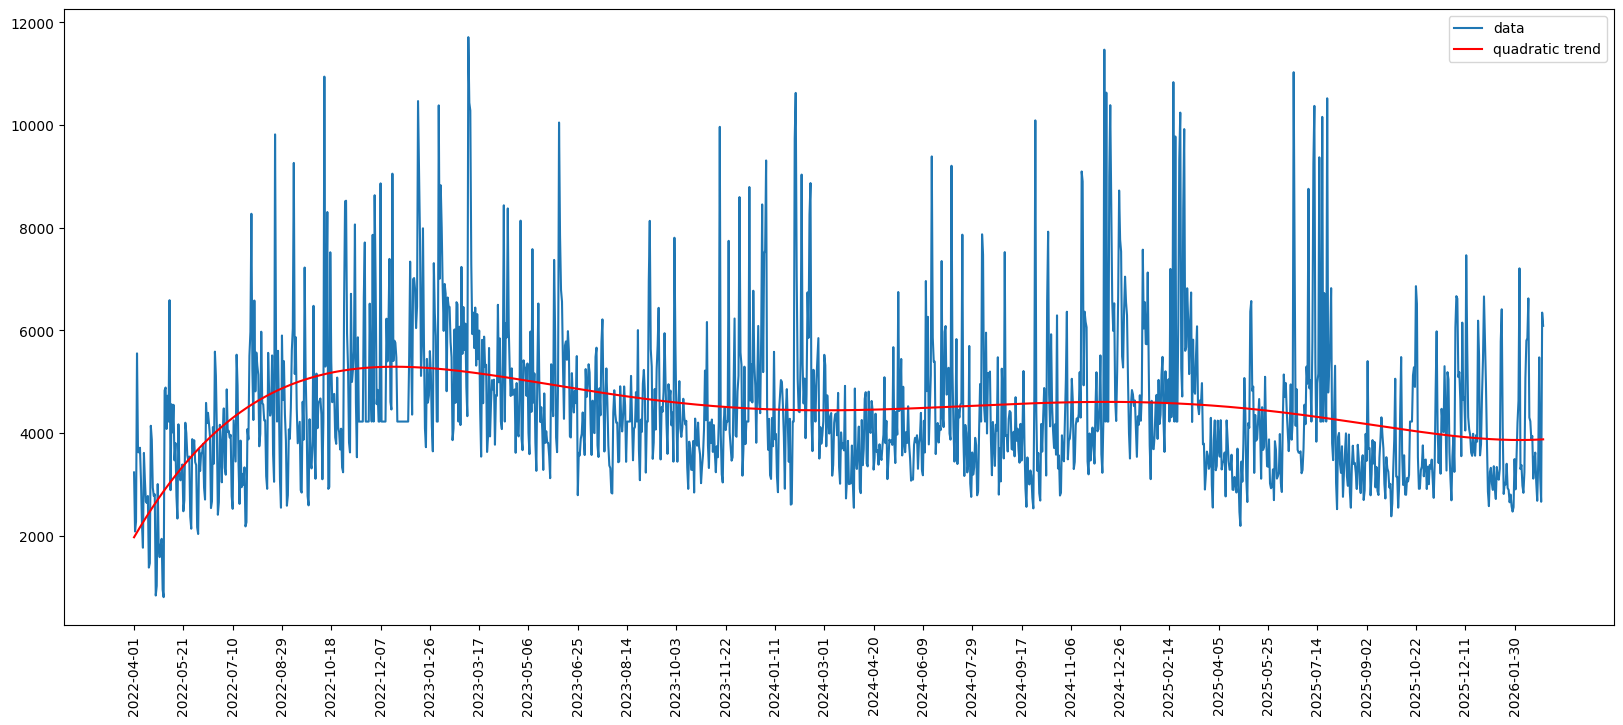

In [10]:
y = donations.values
t = np.arange(len(y))

# апроксимація 2-го степеня
coeffs = np.polyfit(t, y, 5)

# будуємо функцію
trend = np.polyval(coeffs, t)

fig, ax = plt.subplots(figsize=(20, 8))
# графік
ax.plot(y, label="data")
ax.plot(trend, color="red", label="quadratic trend")
plt.legend()

p = [x * 50 for x in range(29)]
ticks = donations.index.date[p]

plt.xticks(p, ticks, rotation=90)

plt.show()

### Спостережувана динаміка ряду свідчить про формування плато на початку 2023 року, що може бути інтерпретовано як наслідок вичерпання початкового мобілізаційного ефекту та переходу системи в більш стабілізований стан. Така стабілізація, ймовірно, обумовлена сукупністю факторів, зокрема зниженням емоційної залученості донорів після тривалого періоду високої напруги, досягненням локального максимуму донатної активності, а також посиленням конкуренції з боку інших благодійних фондів. Додатково, на динаміку міг вплинути перерозподіл донатних потоків після масштабних інформаційних кампаній, а також потенційне зниження купівельної спроможності населення, що обмежує можливості регулярної фінансової підтримки.

<Axes: xlabel='day'>

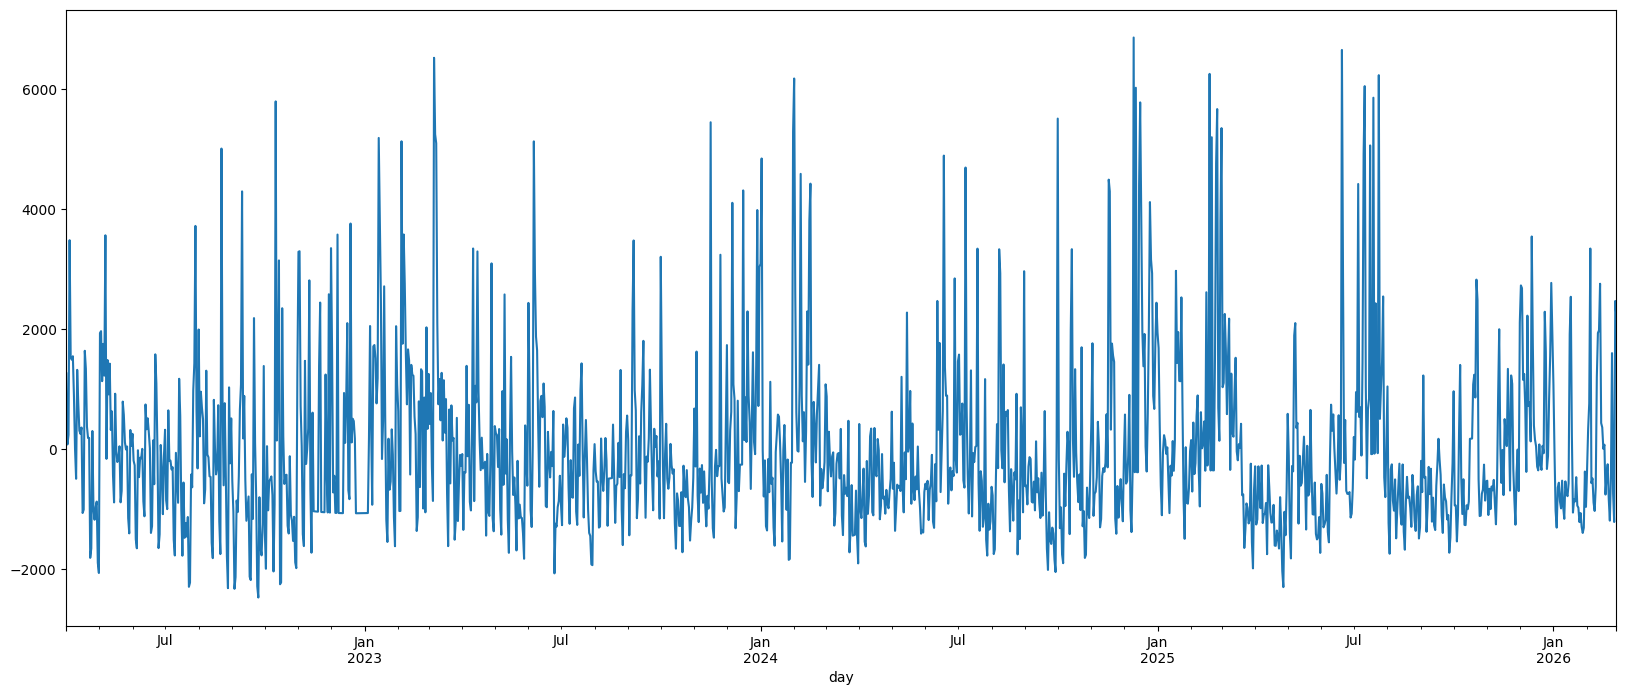

In [11]:
withput_trend = donations.copy()

withput_trend = withput_trend - np.polyval(coeffs, t)

fig, ax = plt.subplots(figsize=(20, 8))
withput_trend.plot(ax=ax)

In [12]:
adf_test(withput_trend)
kpss_test(withput_trend)

Results of Dickey-Fuller Test:
Test Statistic                  -6.08
p-value                          0.00
#Lags Used                      21.00
Number of Observations Used   1408.00
Critical Value (1%)             -3.97
Critical Value (5%)             -3.41
Critical Value (10%)            -3.13
dtype: float64
Results of KPSS Test:
Test Statistic           0.04
p-value                  0.10
Lags Used               19.00
Critical Value (10%)     0.12
Critical Value (5%)      0.15
Critical Value (2.5%)    0.18
Critical Value (1%)      0.22
dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_26448\990589252.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpsstest = kpss(timeseries, regression="ct", nlags="auto")


### Результати тесту Дікі–Фуллера (ADF) свідчать про відсутність одиничного кореня (p-value ≈ 0), що дозволяє відхилити нульову гіпотезу нестаціонарності та зробити висновок про стаціонарність ряду. Водночас результати тесту KPSS (p-value = 0.10) не дають підстав відхиляти гіпотезу стаціонарності. Узгоджені результати обох тестів вказують на те, що часовий ряд є стаціонарним.
### Це свідчить про відсутність вираженої трендової компоненти та стабільність статистичних характеристик ряду в часі.

C:\Users\user\AppData\Local\Temp\ipykernel_26448\1876593681.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  series = withput_trend.resample("M").sum()


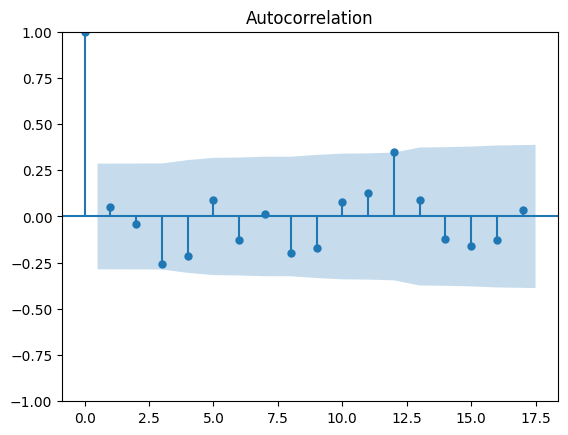

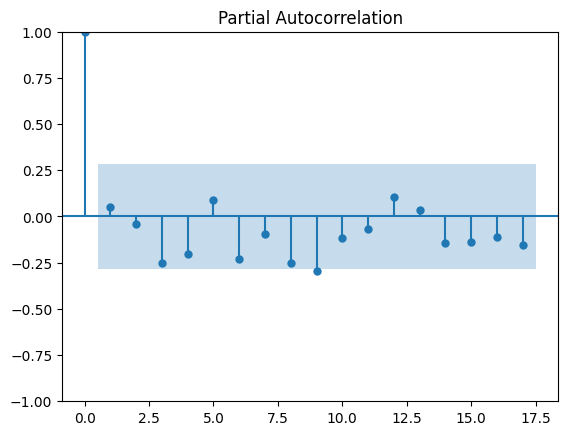

In [13]:
series = withput_trend.resample("M").sum()

plot_acf(series)
plt.show()

plot_pacf(series)
plt.show()

### Аналіз автокореляційної функції виявляє наявність невеликого, проте статистично помітного піку на лагу 12, що відповідає річному періоду. Це може свідчити про наявність слабко вираженої річної сезонності у часовому ряді.

In [18]:
import itertools
import numpy as np
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error


series = donations.resample("W").sum()
# === SPLIT ===
train_size = int(len(series) * 0.8)
train, test = series[:train_size], series[train_size:]

# === NAIVE BASELINE ===
naive_pred = test.shift(1)
naive_mae = mean_absolute_error(test[1:], naive_pred[1:])
print(f"Naive MAE: {naive_mae:.2f}")

# === PARAM GRID ===
p = [1, 2, 3, 4]
d = [0, 1]
q = [0, 1, 2, 3]

P = [0, 1]
D = [0]
Q = [0]
s = [0, 52]

results = []

for param in itertools.product(p, d, q):
    for seasonal in itertools.product(P, D, Q, s):

        try:
            model = SARIMAX(
                train,
                order=param,
                seasonal_order=seasonal,
            )

            model_fit = model.fit(disp=False)

            # === FORECAST ===
            pred = model_fit.forecast(len(test))
            mae = mean_absolute_error(test, pred)

            # === RESIDUALS ===
            residuals = model_fit.resid

            # Ljung-Box
            lb = acorr_ljungbox(residuals, lags=[10], return_df=True)
            lb_p = lb['lb_pvalue'].values[0]

            # p-values
            pvals = model_fit.pvalues
            significant = sum(
                (p < 0.05) for name, p in pvals.items() if "sigma2" not in name
            ) / len(pvals)

            results.append({
                "order": param,
                "seasonal": seasonal,
                "mae": mae,
                "ljungbox_p": lb_p,
                "significance_ratio": significant,
                "better_than_naive": mae < naive_mae
            })

            print(f"{param} x {seasonal} | MAE={mae:.2f} | LB={lb_p:.2f}")

        except:
            continue

results_df = pd.DataFrame(results)

# === ФІЛЬТР ===
filtered = results_df[
    (results_df["ljungbox_p"] > 0.05) &
    (results_df["significance_ratio"] > 0.6) &
    (results_df["better_than_naive"] == True)
]

# === СОРТУВАННЯ ===
filtered = filtered.sort_values("mae", ascending=False)

print("\n=== BEST MODELS ===")
print(filtered.head(10))

print("\n=== ALL TOP BY MAE ===")
print(results_df.sort_values("mae").head(10))

Naive MAE: 5341.52
(1, 0, 0) x (0, 0, 0, 0) | MAE=11034.92 | LB=0.00
(1, 0, 0) x (0, 0, 0, 52) | MAE=11034.92 | LB=0.00
(1, 0, 0) x (1, 0, 0, 52) | MAE=11137.15 | LB=0.00
(1, 0, 1) x (0, 0, 0, 0) | MAE=5055.69 | LB=0.01
(1, 0, 1) x (0, 0, 0, 52) | MAE=5055.69 | LB=0.01
(1, 0, 1) x (1, 0, 0, 52) | MAE=5078.41 | LB=0.01
(1, 0, 2) x (0, 0, 0, 0) | MAE=5024.11 | LB=0.47
(1, 0, 2) x (0, 0, 0, 52) | MAE=5024.11 | LB=0.47
(1, 0, 2) x (1, 0, 0, 52) | MAE=5088.76 | LB=0.45
(1, 0, 3) x (0, 0, 0, 0) | MAE=5026.75 | LB=0.47
(1, 0, 3) x (0, 0, 0, 52) | MAE=5026.75 | LB=0.47
(1, 0, 3) x (1, 0, 0, 52) | MAE=5103.69 | LB=0.45
(1, 1, 0) x (0, 0, 0, 0) | MAE=5432.53 | LB=0.00
(1, 1, 0) x (0, 0, 0, 52) | MAE=5432.53 | LB=0.00
(1, 1, 0) x (1, 0, 0, 52) | MAE=5502.24 | LB=0.00
(1, 1, 1) x (0, 0, 0, 0) | MAE=5218.27 | LB=0.22
(1, 1, 1) x (0, 0, 0, 52) | MAE=5218.27 | LB=0.22
(1, 1, 1) x (1, 0, 0, 52) | MAE=5235.39 | LB=0.19
(1, 1, 2) x (0, 0, 0, 0) | MAE=5126.80 | LB=0.45
(1, 1, 2) x (0, 0, 0, 52) | MAE=512

C:\Users\user\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\user\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\user\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\user\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


(2, 0, 1) x (0, 0, 0, 52) | MAE=5064.84 | LB=0.23


C:\Users\user\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\user\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


(2, 0, 1) x (1, 0, 0, 52) | MAE=5093.13 | LB=0.22
(2, 0, 2) x (0, 0, 0, 0) | MAE=5023.73 | LB=0.47
(2, 0, 2) x (0, 0, 0, 52) | MAE=5023.73 | LB=0.47
(2, 0, 2) x (1, 0, 0, 52) | MAE=5098.17 | LB=0.45
(2, 0, 3) x (0, 0, 0, 0) | MAE=5062.81 | LB=0.53
(2, 0, 3) x (0, 0, 0, 52) | MAE=5062.81 | LB=0.53


...

(4, 1, 3) x (0, 0, 0, 0) | MAE=4952.22 | LB=0.79


C:\Users\user\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\user\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\user\miniconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


(4, 1, 3) x (0, 0, 0, 52) | MAE=4952.22 | LB=0.79


C:\Users\user\miniconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(4, 1, 3) x (1, 0, 0, 52) | MAE=5195.65 | LB=0.82

=== BEST MODELS ===
        order       seasonal     mae  ljungbox_p  significance_ratio  \
36  (2, 1, 0)   (0, 0, 0, 0) 5287.60        0.05                0.67   
37  (2, 1, 0)  (0, 0, 0, 52) 5287.60        0.05                0.67   
82  (4, 0, 3)  (0, 0, 0, 52) 5235.33        0.94                0.88   
81  (4, 0, 3)   (0, 0, 0, 0) 5235.33        0.94                0.88   
69  (3, 1, 3)   (0, 0, 0, 0) 5227.37        0.95                0.86   
70  (3, 1, 3)  (0, 0, 0, 52) 5227.37        0.95                0.86   
15  (1, 1, 1)   (0, 0, 0, 0) 5218.27        0.22                0.67   
16  (1, 1, 1)  (0, 0, 0, 52) 5218.27        0.22                0.67   
95  (4, 1, 3)  (1, 0, 0, 52) 5195.65        0.82                0.67   
47  (2, 1, 3)  (1, 0, 0, 52) 5191.86        0.57                0.71   

    better_than_naive  
36               True  
37               True  
82               True  
81               True  
69              

### У результаті аналізу моделей ARIMA/SARIMA встановлено, що найкращі результати досягаються при використанні диференціювання першого порядку (d=1), що підтверджує наявність слабкої нестаціонарності ряду. Включення сезонної компоненти не дало суттєвого покращення, а загальне зниження похибки відносно наївної моделі є незначним, що свідчить про обмежену передбачуваність та домінування випадкової складової.

### У зв’язку з цим, як модель очікуваних значень використовується декомпозиція ряду, де прогноз формується на основі трендової та сезонної компонент, що відображають систематичну частину процесу, тоді як залишки розглядаються як шум.

day
2022-04-03   3193.18
2022-04-04   6492.69
2022-04-05   3559.49
2022-04-06   4064.30
2022-04-07   4348.14
dtype: float64


<Axes: xlabel='day'>

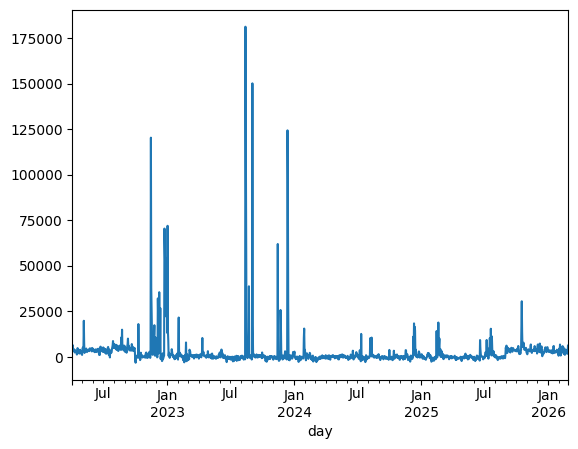

In [20]:
seasonal = decomposition.seasonal
seasonal = seasonal.fillna(0)

trend = decomposition.trend
trend = trend.fillna(0)

expected = (seasonal + trend)

res =  (savelife_df["transactions_count"] - expected)[2:]
res.plot()

### Вплив кампанії оцінюється як ряд - очікувана компонента

In [21]:
res.sort_values()[1400:]

day
2022-12-06    20056.10
2023-02-03    21631.60
2022-12-28    22302.84
2022-11-17    25082.15
2023-11-23    25768.59
2022-12-29    26611.08
2022-12-12    26805.42
2023-12-15    29174.40
2025-10-17    30543.62
2022-12-05    32118.27
2022-12-09    35524.84
2022-11-16    37777.04
2023-08-24    38776.92
2022-12-31    49498.19
2022-12-26    50009.15
2022-12-30    50707.38
2022-12-27    54200.29
2022-12-25    61117.57
2023-11-15    61972.26
2023-08-16    67988.79
2022-12-24    70434.45
2023-01-02    71959.89
2023-12-14    96598.84
2023-08-15   120139.29
2022-11-15   120304.71
2023-12-13   124320.64
2023-09-03   150108.23
2023-08-14   181178.62
dtype: float64

#### 2022-11-15 - Black box https://t.me/savelifeua/1088

#### 2022-12-24 / 25 - Різдво + https://savelife.in.ua/materials/news/strongdovhi-ruky-tro-strongstrongzbyraye/
#### 2023-08-14 / 15 / 16 - https://savelife.in.ua/materials/news/povernys-zhyvym-united24-ta-monobank-zap/
#### 2023-09-03 - Лебігович https://t.me/savelifeua/1703
#### 2023-12-13 - https://savelife.in.ua/materials/news/operatsiya-yednist-2-novorichnyy-salyut/

### Досліджуваний донатний часовий ряд не демонструє наявності вираженої сезонної компоненти, а його динаміка визначається переважно трендовою складовою та суттєвим впливом окремих подієвих факторів. Це свідчить про домінування нерегулярних змін, обумовлених зовнішніми обставинами, над регулярними періодичними коливаннями.